In [3]:
library(data.table)
library(dplyr)
library(ggplot2)
library(stringr)

# Final Version

In [5]:
data <- fread("results/lollipop_plot_data.csv")

head(data)

metabolite,platform_name,super_pathway,sub_pathway,significant_any_challenge,significant_fasting_pat_oltt,challenge_time,challenge,mean_response,log2_foldchange,p_value,neg_log10_p_value,abs_log2_foldchange
<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"1,5-anhydroglucitol (1,5-ag)",Metabolon HD4 [nt-ms],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",FALSE,FALSE,0,Fasting,-0.25972516,0.000000000,0.310763,0.5075707,0.000000000
"1,5-anhydroglucitol (1,5-ag)",Metabolon HD4 [nt-ms],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",FALSE,FALSE,120,Fasting,-0.26698492,-0.007259760,0.310763,0.5075707,0.007259760
"1,5-anhydroglucitol (1,5-ag)",Metabolon HD4 [nt-ms],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",FALSE,FALSE,240,Fasting,-0.08343737,0.176287792,0.310763,0.5075707,0.176287792
"1,5-anhydroglucitol (1,5-ag)",Metabolon HD4 [nt-ms],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",FALSE,FALSE,360,Fasting,-0.15997613,0.099749023,0.310763,0.5075707,0.099749023
"1,5-anhydroglucitol (1,5-ag)",Metabolon HD4 [nt-ms],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",FALSE,FALSE,480,Fasting,-0.07772536,0.181999794,0.310763,0.5075707,0.181999794
"1,5-anhydroglucitol (1,5-ag)",Metabolon HD4 [nt-ms],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",FALSE,FALSE,600,Fasting,-0.26662788,-0.006902722,0.310763,0.5075707,0.006902722


In [9]:
any_sig_data <- data %>%
    filter(significant_any_challenge == TRUE) %>%
    filter(platform_name == "In-house biochemistry [chem.]")

unique(any_sig_data$metabolite)

[1] "glucose" "insulin" "lactate"

In [ ]:
all_metabolites <- fread("results/anova_with_insulin.csv", sep = ",", fill = TRUE) %>%
    filter(platform_name == "In-house biochemistry [chem.]")

head(all_metabolites)

In [23]:
any_sig_data$challenge <- factor(any_sig_data$challenge, levels = c("Fasting", "PAT", "OLTT"))

data <- any_sig_data

create_metabolic_subset <- function(data, metabolite_name) {
  
  processed_data <- data %>%
    filter(metabolite == metabolite_name)
    
  # Ensure challenge is a factor with ordered levels
  processed_data$challenge <- factor(processed_data$challenge, levels = c("Fasting", "PAT", "OLTT"))
  
  return(processed_data)
}

glucose_data <- create_metabolic_subset(data, "glucose")
head(glucose_data)

insulin_data <- create_metabolic_subset(data, "insulin")
head(insulin_data)

lactate_data <- create_metabolic_subset(data, "lactate")
head(lactate_data)


metabolite,platform_name,super_pathway,sub_pathway,significant_any_challenge,significant_fasting_pat_oltt,challenge_time,challenge,mean_response,log2_foldchange,p_value,neg_log10_p_value,abs_log2_foldchange
<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
glucose,In-house biochemistry [chem.],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",TRUE,FALSE,0,Fasting,-0.19814787,0.0000000000,0.04320449,1.364471,0.0000000000
glucose,In-house biochemistry [chem.],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",TRUE,FALSE,120,Fasting,-0.13551821,0.0626296604,0.04320449,1.364471,0.0626296604
glucose,In-house biochemistry [chem.],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",TRUE,FALSE,240,Fasting,-0.07194675,0.1262011202,0.04320449,1.364471,0.1262011202
glucose,In-house biochemistry [chem.],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",TRUE,FALSE,360,Fasting,-0.13598911,0.0621587607,0.04320449,1.364471,0.0621587607
glucose,In-house biochemistry [chem.],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",TRUE,FALSE,480,Fasting,-0.19720607,0.0009417994,0.04320449,1.364471,0.0009417994
glucose,In-house biochemistry [chem.],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",TRUE,FALSE,600,Fasting,-0.34977757,-0.1516297042,0.04320449,1.364471,0.1516297042


metabolite,platform_name,super_pathway,sub_pathway,significant_any_challenge,significant_fasting_pat_oltt,challenge_time,challenge,mean_response,log2_foldchange,p_value,neg_log10_p_value,abs_log2_foldchange
<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
insulin,In-house biochemistry [chem.],Peptides,Peptide Hormone,TRUE,FALSE,0,Fasting,-0.1881778,0.00000000,4.623904e-12,11.33499,0.00000000
insulin,In-house biochemistry [chem.],Peptides,Peptide Hormone,TRUE,FALSE,120,Fasting,-0.2840540,-0.09587619,4.623904e-12,11.33499,0.09587619
insulin,In-house biochemistry [chem.],Peptides,Peptide Hormone,TRUE,FALSE,240,Fasting,-0.3796995,-0.19152163,4.623904e-12,11.33499,0.19152163
insulin,In-house biochemistry [chem.],Peptides,Peptide Hormone,TRUE,FALSE,360,Fasting,-0.3996592,-0.21148141,4.623904e-12,11.33499,0.21148141
insulin,In-house biochemistry [chem.],Peptides,Peptide Hormone,TRUE,FALSE,480,Fasting,-0.4196767,-0.23149889,4.623904e-12,11.33499,0.23149889
insulin,In-house biochemistry [chem.],Peptides,Peptide Hormone,TRUE,FALSE,600,Fasting,-0.4184076,-0.23022977,4.623904e-12,11.33499,0.23022977


metabolite,platform_name,super_pathway,sub_pathway,significant_any_challenge,significant_fasting_pat_oltt,challenge_time,challenge,mean_response,log2_foldchange,p_value,neg_log10_p_value,abs_log2_foldchange
<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
lactate,In-house biochemistry [chem.],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",TRUE,FALSE,0,Fasting,-0.3505207,0.00000000,0.6431521,0.1916863,0.00000000
lactate,In-house biochemistry [chem.],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",TRUE,FALSE,120,Fasting,-0.3763521,-0.02583139,0.6431521,0.1916863,0.02583139
lactate,In-house biochemistry [chem.],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",TRUE,FALSE,240,Fasting,-0.4021835,-0.05166278,0.6431521,0.1916863,0.05166278
lactate,In-house biochemistry [chem.],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",TRUE,FALSE,360,Fasting,-0.3909525,-0.04043174,0.6431521,0.1916863,0.04043174
lactate,In-house biochemistry [chem.],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",TRUE,FALSE,480,Fasting,-0.3797214,-0.02920070,0.6431521,0.1916863,0.02920070
lactate,In-house biochemistry [chem.],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",TRUE,FALSE,600,Fasting,-0.3916263,-0.04110560,0.6431521,0.1916863,0.04110560


In [15]:
all_combined_data <- bind_rows(glucose_data, insulin_data, lactate_data)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


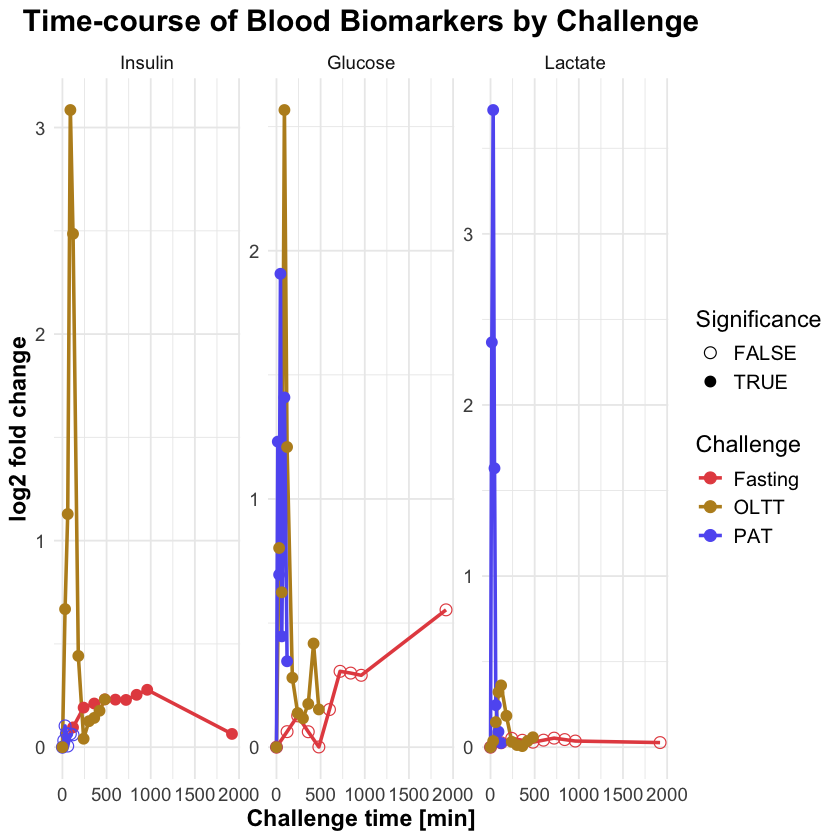

In [17]:
plot_time_course_selected <- function(data) {
  
  # Define significance mapping
  significance_mapping <- tibble(
    metabolite = c("insulin", "insulin", "insulin",
                   "glucose", "glucose", "glucose",
                   "lactate", "lactate", "lactate"),
    challenge = c("Fasting", "OLTT", "PAT",
                  "Fasting", "PAT", "OLTT",
                  "Fasting", "PAT", "OLTT"),
    significant = c(TRUE, TRUE, FALSE, 
                    FALSE, TRUE, TRUE, 
                    FALSE, TRUE, TRUE)  # TRUE means significant
  )

  # Merge significance info into data
  data_annotated <- data %>%
    left_join(significance_mapping, by = c("metabolite", "challenge")) %>%
    mutate(
      metabolite = factor(metabolite, levels = c("insulin", "glucose", "lactate")),  # Set order
      metabolite_label = factor(str_to_title(metabolite), levels = c("Insulin", "Glucose", "Lactate"))  # Label for facets
    )

  # Define colors for challenges
  challenge_colors <- c("Fasting" = "#e55050", "PAT" = "#6160f2", "OLTT" = "#ba8e23")

  # Create time-course plot
  p <- ggplot(data_annotated, aes(x = challenge_time, y = abs_log2_foldchange, 
                                  color = challenge, group = challenge)) +
    geom_line(size = 1) +  
    geom_point(aes(shape = significant), size = 3, fill = "white") +  # Shape defines filled/hollow points
    scale_shape_manual(values = c("TRUE" = 16, "FALSE" = 1)) +  # Fixed syntax
    scale_color_manual(values = challenge_colors) +
    labs(
      title = "Time-course of Blood Biomarkers by Challenge",
      x = "Challenge time [min]",
      y = "log2 fold change",
      color = "Challenge",
      shape = "Significance"  # Legend for significance
    ) +
    theme_minimal() +
    theme(
      text = element_text(size = 14),
      plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
      axis.title = element_text(face = "bold", size = 14),
      legend.position = "right",
      legend.text = element_text(size = 12)
    ) +
    facet_wrap(~metabolite_label, scales = "free")  # Facet by metabolite

  # Save the plot
  output_path <- "results/selected_time_course_plot_significance.png"
  ggsave(output_path, plot = p, width = 15, height = 5, dpi = 300, bg = "white")
  
  return(p)  
}

# Example usage:
plot_time_course_selected(all_combined_data)

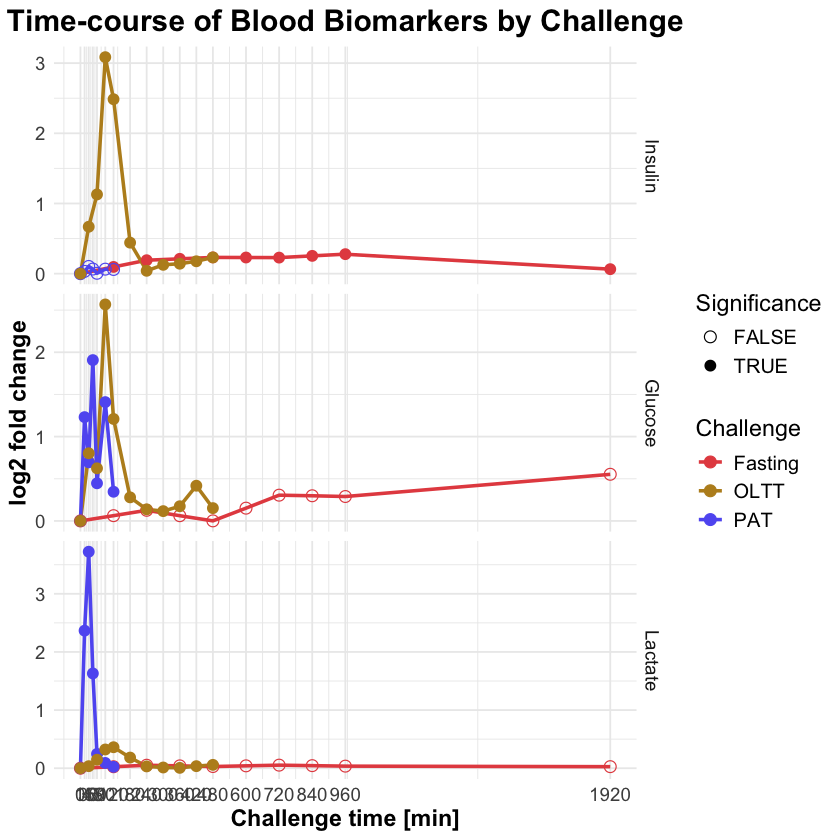

In [19]:
plot_time_course_selected <- function(data) {
  
  # Define significance mapping
  significance_mapping <- tibble(
    metabolite = c("insulin", "insulin", "insulin",
                   "glucose", "glucose", "glucose",
                   "lactate", "lactate", "lactate"),
    challenge = c("Fasting", "OLTT", "PAT",
                  "Fasting", "PAT", "OLTT",
                  "Fasting", "PAT", "OLTT"),
    significant = c(TRUE, TRUE, FALSE, 
                    FALSE, TRUE, TRUE, 
                    FALSE, TRUE, TRUE)  # TRUE means significant
  )

  # Merge significance info into data
  data_annotated <- data %>%
    left_join(significance_mapping, by = c("metabolite", "challenge")) %>%
    mutate(
      metabolite = factor(metabolite, levels = c("insulin", "glucose", "lactate")),  # Set order
      metabolite_label = factor(str_to_title(metabolite), levels = c("Insulin", "Glucose", "Lactate"))  # Label for facets
    )

  # Define colors for challenges
  challenge_colors <- c("Fasting" = "#e55050", "PAT" = "#6160f2", "OLTT" = "#ba8e23")

  # Create time-course plot
  p <- ggplot(data_annotated, aes(x = challenge_time, y = abs_log2_foldchange, 
                                  color = challenge, group = challenge)) +
    geom_line(size = 1) +  
    geom_point(aes(shape = significant), size = 3, fill = "white") +  # Shape defines filled/hollow points
    scale_shape_manual(values = c("TRUE" = 16, "FALSE" = 1)) +  # Filled (16) for significant, hollow (1) for non-significant
    scale_x_continuous(breaks = unique(data_annotated$challenge_time)) +  # Set only actual challenge times
    scale_color_manual(values = challenge_colors) +
    labs(
      title = "Time-course of Blood Biomarkers by Challenge",
      x = "Challenge time [min]",
      y = "log2 fold change",
      color = "Challenge",
      shape = "Significance"  # Legend for significance
    ) +
    theme_minimal() +
    theme(
      text = element_text(size = 14),
      plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
      axis.title = element_text(face = "bold", size = 14),
      legend.position = "right",
      legend.text = element_text(size = 12)
    ) +
    facet_grid(metabolite_label ~ ., scales = "free")  # Display biomarkers vertically

  # Save the plot
  output_path <- "results/selected_time_course_plot_limited_time_top_all.png"
  ggsave(output_path, plot = p, width = 10, height = 10, dpi = 300, bg = "white")
  
  return(p)  
}

# Example usage:
plot_time_course_selected(all_combined_data)

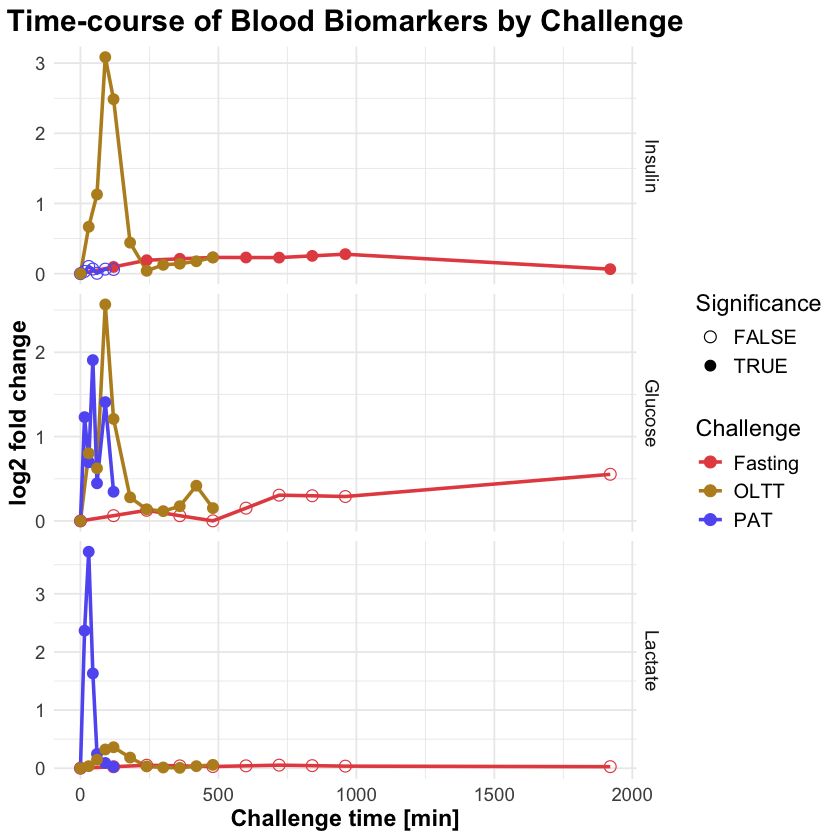

In [21]:
plot_time_course_selected <- function(data) {
  
  # Define significance mapping
  significance_mapping <- tibble(
    metabolite = c("insulin", "insulin", "insulin",
                   "glucose", "glucose", "glucose",
                   "lactate", "lactate", "lactate"),
    challenge = c("Fasting", "OLTT", "PAT",
                  "Fasting", "PAT", "OLTT",
                  "Fasting", "PAT", "OLTT"),
    significant = c(TRUE, TRUE, FALSE, 
                    FALSE, TRUE, TRUE, 
                    FALSE, TRUE, TRUE)  # TRUE means significant
  )

  # Merge significance info into data
  data_annotated <- data %>%
    left_join(significance_mapping, by = c("metabolite", "challenge")) %>%
    mutate(
      metabolite = factor(metabolite, levels = c("insulin", "glucose", "lactate")),  # Set order
      metabolite_label = factor(str_to_title(metabolite), levels = c("Insulin", "Glucose", "Lactate"))  # Label for facets
    )

  # Define colors for challenges
  challenge_colors <- c("Fasting" = "#e55050", "PAT" = "#6160f2", "OLTT" = "#ba8e23")

  # Create time-course plot
  p <- ggplot(data_annotated, aes(x = challenge_time, y = abs_log2_foldchange, 
                                  color = challenge, group = challenge)) +
    geom_line(size = 1) +  
    geom_point(aes(shape = significant), size = 3, fill = "white") +  # Shape defines filled/hollow points
    scale_shape_manual(values = c("TRUE" = 16, "FALSE" = 1)) +  # Filled (16) for significant, hollow (1) for non-significant
    scale_color_manual(values = challenge_colors) +
    labs(
      title = "Time-course of Blood Biomarkers by Challenge",
      x = "Challenge time [min]",
      y = "log2 fold change",
      color = "Challenge",
      shape = "Significance"  # Legend for significance
    ) +
    theme_minimal() +
    theme(
      text = element_text(size = 14),
      plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
      axis.title = element_text(face = "bold", size = 14),
      legend.position = "right",
      legend.text = element_text(size = 12)
    ) +
    facet_grid(metabolite_label ~ ., scales = "free")  # Stack plots vertically

  # Save the plot
  output_path <- "results/selected_time_course_plot_under_significance_allll.png"
  ggsave(output_path, plot = p, width = 10, height = 10, dpi = 300, bg = "white")
  
  return(p)  
}

# Example usage:
plot_time_course_selected(all_combined_data)


In [25]:
filtered_glucose_data <- glucose_data[glucose_data$challenge %in% c("PAT", "OLTT"), ]

filtered_insulin_data <- insulin_data[insulin_data$challenge %in% c("Fasting", "OLTT"), ]

filtered_lactate_data <- lactate_data[lactate_data$challenge %in% c("PAT", "OLTT"), ]

In [27]:
# Assign colors for challenges
challenge_colors <- c(
  "Fasting" = "#e55050",
  "PAT" = "#6160f2",
  "OLTT" = "#ba8e23"
)

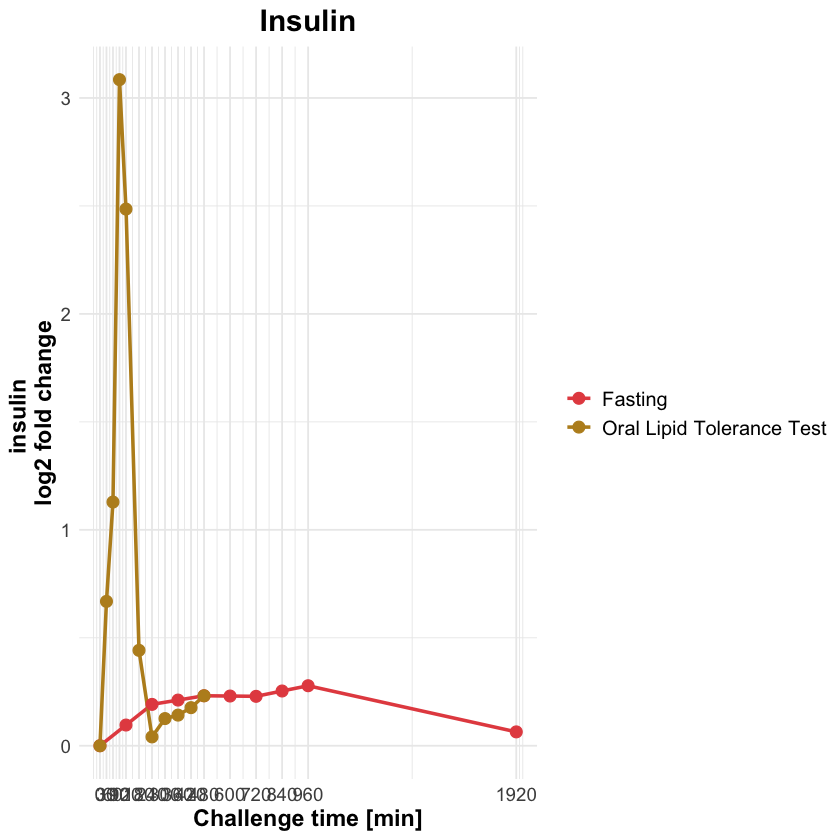

In [30]:
plot_time_course <- function(data, metabolite_name) {

  # Create time-course plot
  p <- ggplot(data, aes(x = challenge_time, y = abs_log2_foldchange, color = challenge, group = challenge)) +
    geom_line(size = 1) +  # Line plot for each challenge
    geom_point(size = 3) +  # Add points at data points
    scale_x_continuous(breaks = sort(unique(data$challenge_time))) +  # Only show actual challenge times
    scale_color_manual(values = challenge_colors, 
                       labels = c("Fasting" = "Fasting",
                                  "PAT" = "Physical Activity",
                                  "OLTT" = "Oral Lipid Tolerance Test")) +
    labs(
      title = str_to_title(metabolite_name),
      x = "Challenge time [min]",
      y = paste(metabolite_name, "\nlog2 fold change"),
      color = NULL
    ) +
    theme_minimal() +
    theme(
      text = element_text(size = 14),
      plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
      axis.title = element_text(face = "bold", size = 14),
      legend.position = "right",
      legend.title = element_blank(),  # Removes default legend title
      legend.text = element_text(size = 12)
    )

  # Save the plot
  output_path <- paste0("results/", metabolite_name, "_time_course_plot.png")
  ggsave(output_path, plot = p, width = 20, height = 5, dpi = 300, bg = "white")
  
  return(p)  # Return the plot object
}

plot_time_course(filtered_insulin_data, "insulin")

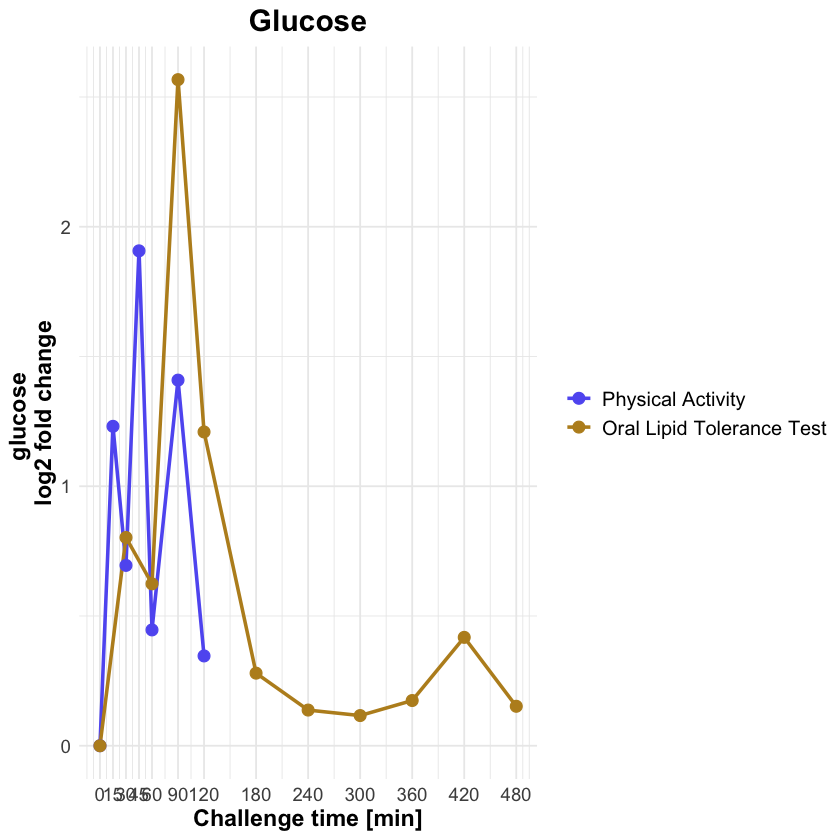

In [32]:
plot_time_course(filtered_glucose_data, "glucose")

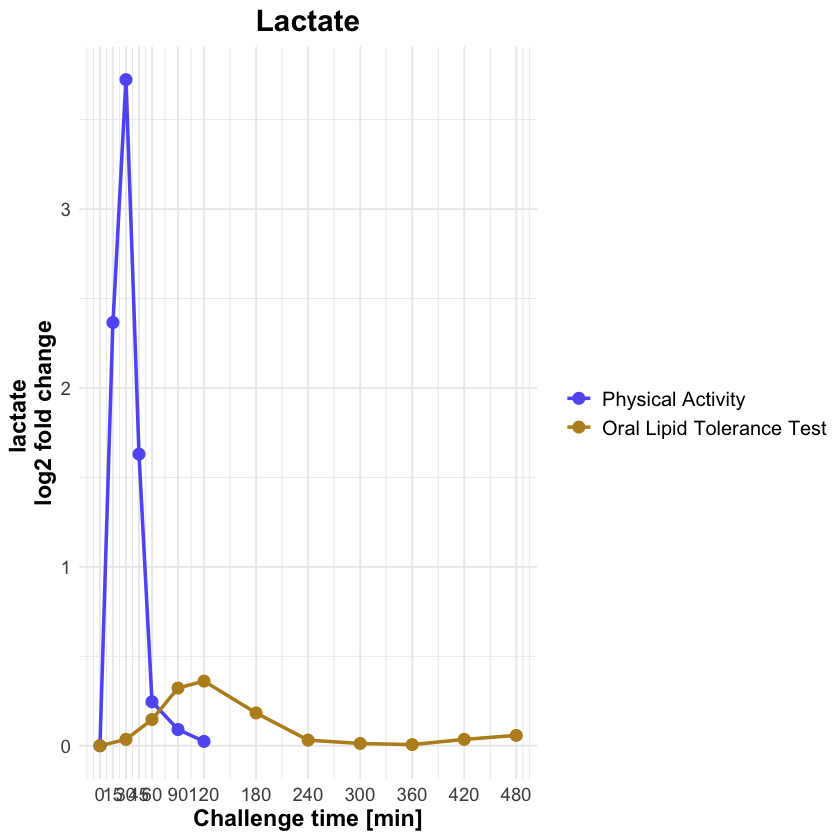

In [34]:
plot_time_course(filtered_lactate_data, "lactate")

In [37]:
filtered_insulin_data_challenge_time_limited <- filtered_insulin_data %>%
    filter(challenge_time < 500)

# Extract unique challenge times to use as x-axis breaks
insulin_limited_times <- sort(unique(filtered_insulin_data_challenge_time_limited$challenge_time))
insulin_limited_times

[1]   0  30  60  90 120 180 240 300 360 420 480

In [39]:
# Combine all datasets into one
comparable_times_combined_data <- bind_rows(filtered_insulin_data_challenge_time_limited, 
                                            filtered_glucose_data, filtered_lactate_data)

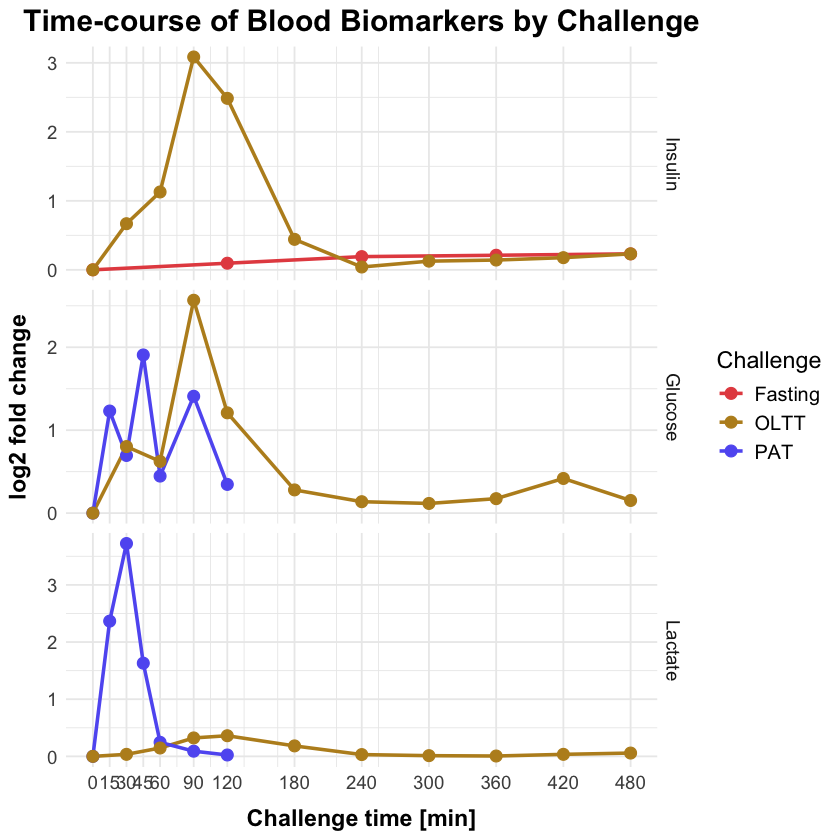

In [51]:
plot_time_course_selected <- function(data) {
  
  # Define valid challenge-metabolite pairs
  valid_combinations <- tibble(
    metabolite = c("insulin", "insulin", "glucose", "glucose", "lactate", "lactate"),
    challenge = c("Fasting", "OLTT", "PAT", "OLTT", "PAT", "OLTT")
  )

  # Filter for the valid combinations
  data_filtered <- data %>%
    inner_join(valid_combinations, by = c("metabolite", "challenge")) %>%
    mutate(
      metabolite = factor(metabolite, levels = c("insulin", "glucose", "lactate")),  # Order for sorting
      metabolite_label = factor(str_to_title(metabolite), levels = c("Insulin", "Glucose", "Lactate"))  # Correct facet order
    )

  # Define colors for challenges
  challenge_colors <- c("Fasting" = "#e55050", "PAT" = "#6160f2", "OLTT" = "#ba8e23")

  # Create time-course plot
  p <- ggplot(data_filtered, aes(x = challenge_time, y = abs_log2_foldchange, 
                                 color = challenge, group = challenge)) +
    geom_line(size = 1) +  
    geom_point(size = 3) +  
    scale_x_continuous(breaks = unique(data_filtered$challenge_time)) +  # Set only actual challenge times
    scale_color_manual(values = challenge_colors) +
    labs(
      title = "Time-course of Blood Biomarkers by Challenge",
      x = "Challenge time [min]",
      y = "log2 fold change",
      color = "Challenge"
    ) +
    theme_minimal() +
    theme(
      text = element_text(size = 14),
      plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
      axis.title = element_text(face = "bold", size = 14),
      axis.title.x = element_text(margin = margin(t = 10)),  # Add space above x-axis label
      axis.title.y = element_text(margin = margin(r = 10)),  # Add space to the right of y-axis label
      legend.position = "right",
      legend.text = element_text(size = 12)
    ) +
    facet_grid(metabolite_label ~ ., scales = "free")  # Display biomarkers vertically

  # Save the plot
  output_path <- "results/selected_time_course_plot_limited_time_top_space.png"
  ggsave(output_path, plot = p, width = 10, height = 10, dpi = 300, bg = "white")
  
  return(p)  
}

# Example usage:
plot_time_course_selected(comparable_times_combined_data)


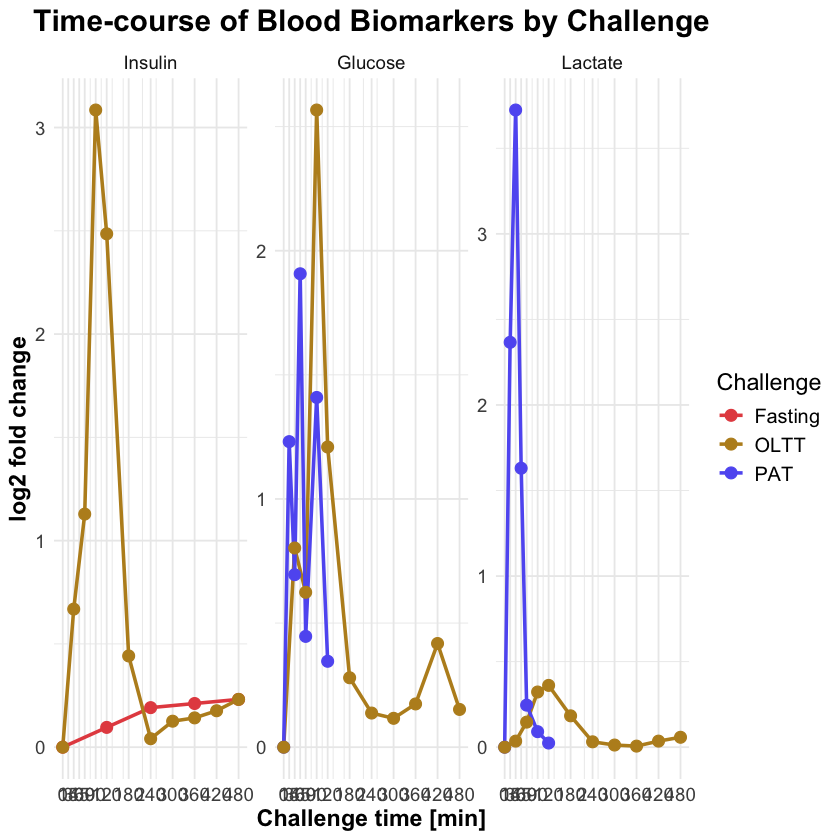

In [46]:
plot_time_course_selected <- function(data) {
  
  # Define valid challenge-metabolite pairs
  valid_combinations <- tibble(
    metabolite = c("insulin", "insulin", "glucose", "glucose", "lactate", "lactate"),
    challenge = c("Fasting", "OLTT", "PAT", "OLTT", "PAT", "OLTT")
  )

  # Filter for the valid combinations
  data_filtered <- data %>%
    inner_join(valid_combinations, by = c("metabolite", "challenge")) %>%
    mutate(
      metabolite = factor(metabolite, levels = c("insulin", "glucose", "lactate")),  # Order for sorting
      metabolite_label = factor(str_to_title(metabolite), levels = c("Insulin", "Glucose", "Lactate"))  # Correct facet order
    )

  # Define colors for challenges
  challenge_colors <- c("Fasting" = "#e55050", "PAT" = "#6160f2", "OLTT" = "#ba8e23")

  # Create time-course plot
  p <- ggplot(data_filtered, aes(x = challenge_time, y = abs_log2_foldchange, 
                                 color = challenge, group = challenge)) +
    geom_line(size = 1) +  
    geom_point(size = 3) +  
    scale_x_continuous(breaks = unique(data_filtered$challenge_time)) +  # Match actual time points
    scale_color_manual(values = challenge_colors) +
    labs(
      title = "Time-course of Blood Biomarkers by Challenge",
      x = "Challenge time [min]",
      y = "log2 fold change",
      color = "Challenge"
    ) +
    theme_minimal() +
    theme(
      text = element_text(size = 14),
      plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
      axis.title = element_text(face = "bold", size = 14),
      legend.position = "right",
      legend.text = element_text(size = 12)
    ) +
    facet_wrap(~metabolite_label, scales = "free")  # Facet by metabolite, keeping x-axis free

  # Save the plot
  output_path <- "results/selected_time_course_plot_limited_time_side.png"
  ggsave(output_path, plot = p, width = 20, height = 7, dpi = 300, bg = "white")
  
  return(p)  
}

# Example usage:
plot_time_course_selected(comparable_times_combined_data)
